In [14]:

import glob
import os
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

from koger_detection.utils.json import create_empty_annotation_json


In [3]:
image_names = [
    "pr351_by2023_survey1_flight2_06140_20240625_105306",
    "pr351_by2023_survey1_flight2_03944_20240625_094804",
    "pr351_by2023_survey1_flight3_07454_20240625_133800",
    "pr351_by2023_survey1_flight3_06358_20240625_130514",
    "pr351_by2023_survey1_flight2_02385_20240625_082531",
    "pr351_by2023_survey1_flight2_02964_20240625_091434",
    "pr351_by2023_survey1_flight3_07043_20240625_132510",
    "pr351_by2023_survey1_flight2_01490_20240625_075723",
    "pr351_by2023_survey1_flight2_04154_20240625_095348",
    "pr351_by2023_survey1_flight2_04453_20240625_100154",
    "pr351_by2023_survey1_flight2_06139_20240625_105305",
    "pr351_by2023_survey1_flight2_02414_20240625_082619",
    "pr351_by2023_survey1_flight2_03463_20240625_093149",
    "pr351_by2023_survey1_flight2_06020_20240625_104944",
    "pr351_by2023_survey1_flight2_02932_20240625_091342",
    "pr351_by2023_survey1_flight2_04103_20240625_095224",
    "pr351_by2023_survey1_flight2_02040_20240625_081557",
    "pr351_by2023_survey1_flight2_00994_20240625_074244",
    "pr351_by2023_survey1_flight2_02391_20240625_082541",
    "pr351_by2023_survey1_flight1_00149_20240624_201333",
    "pr351_by2023_survey1_flight1_00141_20240624_201317",
    "pr412_by2023_survey1_flight2_05259_20240620_084628",
    "pr412_by2023_survey1_flight1_02477_20240617_095527",
    "pr412_by2023_survey1_flight1_01096_20240617_085557",
    "pr412_by2023_survey1_flight1_00989_20240617_085126",
    "pr412_by2023_survey1_flight2_06497_20240620_092516",
    "pr412_by2023_survey1_flight3_09113_20240620_150636",
    "pr412_by2023_survey1_flight2_07265_20240620_095055",
    "pr412_by2023_survey1_flight1_01550_20240617_091626",
    "pr412_by2023_survey1_flight1_00609_20240617_083556",
    "pr412_by2023_survey1_flight2_07689_20240620_100259",
    "pr412_by2023_survey1_flight2_05057_20240620_084006",
    "pr412_by2023_survey1_flight2_08738_20240620_103906",
    "pr412_by2023_survey1_flight2_04514_20240620_082343",
    "pr412_by2023_survey1_flight3_10037_20240620_153841",
    "pr412_by2023_survey1_flight2_05148_20240620_084246",
    "pr412_by2023_survey1_flight1_00996_20240617_085145",
    "pr412_by2023_survey1_flight3_09482_20240620_151902",
    "pr527_by2023_survey1_flight1_01898_20240627_130438",
    "pr527_by2023_survey1_flight1_00458_20240627_121734",
    "pr527_by2023_survey1_flight1_01863_20240627_130322",
    "pr527_by2023_survey1_flight1_01107_20240627_123841",
    "pr527_by2023_survey1_flight1_05216_20240627_153713",
    "pr527_by2023_survey1_flight1_05226_20240627_153730",
    "pr527_by2023_survey1_flight1_04449_20240627_143227",
    "pr527_by2023_survey1_flight1_05496_20240627_155117",
    "pr527_by2023_survey1_flight1_04141_20240627_142355",
    "pr527_by2023_survey1_flight1_03782_20240627_140848",
    "pr527_by2023_survey1_flight1_02462_20240627_132316",
    "pr527_by2023_survey1_flight1_05211_20240627_153705",
    "pr527_by2023_survey1_flight1_02306_20240627_131759",
    "pr527_by2023_survey1_flight1_03442_20240627_135744",
    "pr527_by2023_survey1_flight1_04226_20240627_142713",
    "pr527_by2023_survey1_flight1_05122_20240627_153436",
    "pr527_by2023_survey1_flight1_05208_20240627_153701",
    "pr527_by2023_survey1_flight1_04122_20240627_142325",
    "pr527_by2023_survey1_flight1_05210_20240627_153704",
    "pr527_by2023_survey1_flight1_03953_20240627_141409",
    "pr527_by2023_survey1_flight1_04688_20240627_144827",
    "pr527_by2023_survey1_flight1_04304_20240627_142903",
    "pr527_by2023_survey1_flight1_04081_20240627_142225",
    "pr527_by2023_survey1_flight1_03093_20240627_134628",
    "pr527_by2023_survey1_flight1_01185_20240627_124123",
    "pr527_by2023_survey1_flight1_04075_20240627_142216",
    "pr527_by2023_survey1_flight1_03441_20240627_135742",
    "pr527_by2023_survey1_flight1_00481_20240627_121816",
    "pr527_by2023_survey1_flight1_02353_20240627_131928",
    "pr527_by2023_survey1_flight1_01805_20240627_130113",
    "pr527_by2023_survey1_flight1_02519_20240627_133102",
    "pr527_by2023_survey1_flight1_02305_20240627_131757",
    "pr527_by2023_survey1_flight1_01953_20240627_130621",
    "pr527_by2023_survey1_flight1_05190_20240627_153631",
    "pr527_by2023_survey1_flight1_00981_20240627_123439",
    "pr527_by2023_survey1_flight1_00111_20240627_115959",
    "pr527_by2023_survey1_flight1_03415_20240627_135649",
    "pr527_by2023_survey1_flight1_04187_20240627_142507",
    "pr527_by2023_survey1_flight1_00224_20240627_120332",
    "pr527_by2023_survey1_flight1_02568_20240627_133234",
    "pr527_by2023_survey1_flight1_01822_20240627_130148",
    "pr527_by2023_survey1_flight1_00352_20240627_121421",
    "pr527_by2023_survey1_flight1_01897_20240627_130436",
    "pr527_by2023_survey1_flight1_04806_20240627_152253",
    "pr527_by2023_survey1_flight1_02135_20240627_131214",
    "pr527_by2023_survey1_flight1_02989_20240627_134346",
    "pr527_by2023_survey1_flight1_00552_20240627_122018",
    "pr527_by2023_survey1_flight1_04303_20240627_142901",
    "pr527_by2023_survey1_flight1_04676_20240627_144759",
    "pr527_by2023_survey1_flight1_03769_20240627_140824",
    "pr527_by2023_survey1_flight1_05718_20240627_155940",
    "pr527_by2023_survey1_flight1_04362_20240627_143023",
    "pr527_by2023_survey1_flight1_03737_20240627_140724",
    "pr527_by2023_survey1_flight1_00514_20240627_121916",
    "pr527_by2023_survey1_flight1_02236_20240627_131536"
]

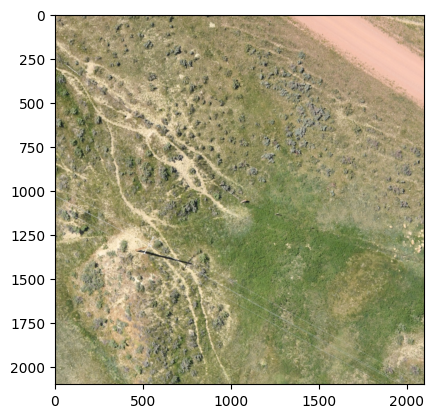

In [ ]:
herd_to_model = {
    "pr527": "10-25-2024-16-50-17",
    "pr412": "02-05-2025-17-36-37",
    "pr351": "03-07-2025-14-17-42"
}


base_json_file = "/home/koger/Projects/pronghorn-census/annotations/pronghorn-survey/train-pr527-pr412-pr351.json"
with open(base_json_file, "r") as read_file:
    base_json = json.load(read_file)

json_dict = create_empty_annotation_json(base_json)

images_folder = "/mnt/h/Pronghorn Vertical Imagery/2024/"
output_folder = os.path.join("/home/koger/pronghorn-processing")
crop_folder = "/home/koger/Projects/pronghorn-census/annotations/pronghorn-survey/images"
pronghorn_class = 2
crop_size = 2100

for im_ind, image_name in enumerate(image_names):
    herd = image_name.split("_")[0]
    image_file = os.path.join(images_folder, herd, f"{image_name}.JPG")
    os.path.exists(image_file) or print(f"Image file does not exist: {image_file}")
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes = np.load(os.path.join(output_folder, herd_to_model[herd], f"{image_name}_boxes.npy"))
    scores = np.load(os.path.join(output_folder, herd_to_model[herd], f"{image_name}_scores.npy"))
    labels = np.load(os.path.join(output_folder, herd_to_model[herd], f"{image_name}_labels.npy"))

    is_pronghorn = labels == pronghorn_class
    boxes = boxes[is_pronghorn]
    scores = scores[is_pronghorn]
    labels = labels[is_pronghorn]
    box = boxes[np.argmax(scores)]

    x1, y1, x2, y2 = box
    crop_x1 = int(max(0, x1 - crop_size // 2))
    crop_y1 = int(max(0, y1 - crop_size // 2))
    crop_x2 = crop_x1 + crop_size
    crop_y2 = crop_y1 + crop_size

    if crop_x2 > image.shape[1]:
        crop_x2 = image.shape[1]
        crop_x1 = crop_x2 - crop_size
    if crop_y2 > image.shape[0]:
        crop_y2 = image.shape[0]
        crop_y1 = crop_y2 - crop_size

    crop = image[crop_y1:crop_y2, crop_x1:crop_x2]

    save_name = f"background_{image_name}_crop_0.JPG"

    im_info = {
                "license": 1,
                "file_name": save_name,
                "height": 2100,
                "width": 2100,
                "date_captured": "",
                "id": im_ind,
                "coco_url": ""
            }

    json_dict['images'].append(im_info)

# cv2.imwrite(os.path.join(crop_folder, save_name), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 100])
# plt.imshow(crop)

In [19]:
json_dict['images']

[]

In [ ]:
{
            "license": 1,
            "file_name": "high-altitude-pronghorn-survey-pr527_by2023_survey1_flight1_00214_20240627_120314_crop_02.JPG",
            "height": 2100,
            "width": 2100,
            "date_captured": "2024-09-26T20:00:53.000+00:00",
            "id": 0,
            "coco_url": "https://storage.labelbox.com/clsc8t1jp03mw07wy9sqk0lc1%2F23f641ae-84ad-6844-f238-e213219bf571-pr527_by2023_survey1_flight1_00214_20240627_120314_crop_02.JPG?Expires=1738887893393&KeyName=labelbox-assets-key-3&Signature=ViJ-_DZGyekP1qC7enkkkkxSJEA"
        },